TensorFlow version: 2.19.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,851 (30.67 KB)

 Trainable params: 7,851 (30.67 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 500, Loss: 3.1016e-02
Epoch 1000, Loss: 2.8295e-02
Epoch 1500, Loss: 2.7124e-02
Epoch 2000, Loss: 2.6534e-02
Epoch 2500, Loss: 2.6001e-02
Epoch 3000, Loss: 2.5353e-02
Epoch 3500, Loss: 2.4263e-02
Epoch 4000, Loss: 2.1584e-02
Epoch 4500, Loss: 1.5056e-02
Epoch 5000, Loss: 1.0724e-02
Epoch 5500, Loss: 9.0048e-03
Epoch 6000, Loss: 9.3941e-03
Epoch 6500, Loss: 6.3533e-03
Epoch 7000, Loss: 5.6342e-03
Epoch 7500, Loss: 5.1722e-03
Epoch 8000, Loss: 4.8483e-03
Epoch 8500, Loss: 4.5983e-03
Epoch 9000, Loss: 4.3866e-03
Epoch 9500, Loss: 4.2900e-03
Epoch 10000, Loss: 4.0020e-03


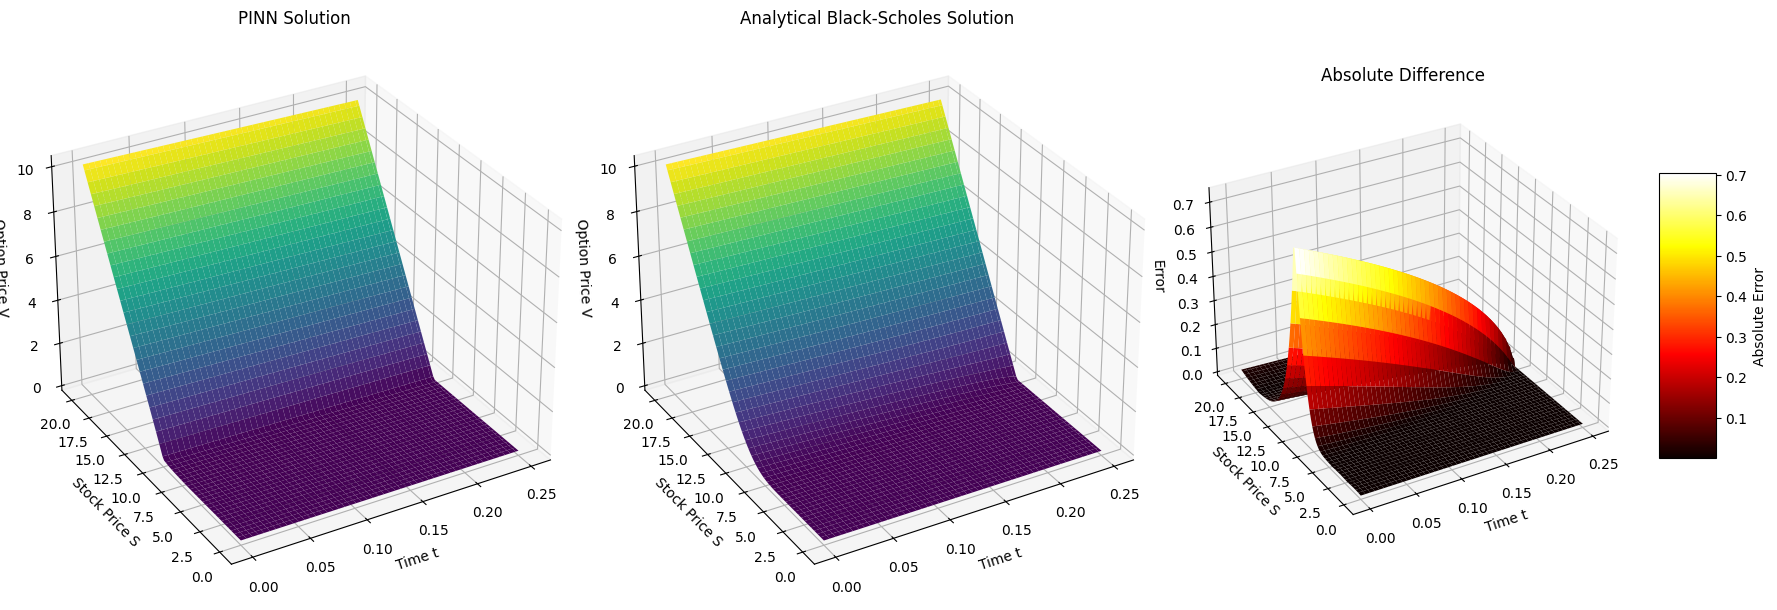

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Step 1: Imports and Setup ---
# Set data type for TensorFlow for efficiency
DTYPE = 'float32'
tf.keras.backend.set_floatx(DTYPE)

print("TensorFlow version:", tf.__version__)

# --- Step 2: Define Problem Parameters ---
# Financial parameters as requested by the user
T = 0.25        # Time to maturity (in years)
K = 10.0        # Strike price
r = 0.1         # Risk-free interest rate
sigma = 0.4     # Volatility

# Computational domain boundaries
S_min = 0.0
S_max = 20.0    # Adjusted to be relative to the new strike price
t_min = 0.0
t_max = T

# --- Step 3: Build the Neural Network ---
# This network learns a "correction" function N(t, S), not the price V directly.
def build_model(num_hidden_layers=4, num_neurons=50):
    """Builds the neural network that approximates N(t, S)."""
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=(2,)))
    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_neurons, activation='tanh',
                                        kernel_initializer='glorot_normal'))
    model.add(tf.keras.layers.Dense(1, activation=None)) # Linear output for N
    return model

# Instantiate the model
pinn_N_model = build_model()
pinn_N_model.summary()

# --- Step 4: Define the Trial Solution and Loss Function ---
# This section implements the robust trial solution method.

def get_V(model, t, S):
    """
    Constructs the trial solution V(t, S) using the network N(t, S).
    This mathematical structure inherently satisfies the boundary conditions
    for a European call option, leading to much better convergence.
    """
    # The payoff for a call option. This is the known value at expiration.
    payoff = tf.maximum(S - K, 0.0)

    # The neural network learns the function N(t, S)
    N = model(tf.concat([t, S], axis=1))

    # A blending function that is zero at t=T and S=0.
    # This ensures the network's contribution disappears at the boundaries,
    # leaving only the correct payoff/boundary value.
    f = (T - t) * S

    # The final trial solution.
    V = payoff + f * N

    return V

def loss_fn(model, t, S):
    """
    Computes the loss function. Because the boundary conditions are satisfied
    by the structure of get_V, the loss only needs to enforce the PDE.
    """
    # Use GradientTape to compute derivatives of the trial solution V
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([t, S])
        with tf.GradientTape(persistent=True) as inner_tape:
            inner_tape.watch([t, S])
            V = get_V(model, t, S)

        # First-order partial derivatives of V
        V_t = inner_tape.gradient(V, t)
        V_S = inner_tape.gradient(V, S)

    # Second-order partial derivative of V
    V_SS = tape.gradient(V_S, S)
    del tape

    # The Black-Scholes PDE residual
    residual = V_t + 0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V

    # The loss is the mean squared error of the PDE residual
    loss = tf.reduce_mean(tf.square(residual))
    return loss

# --- Step 5: Generate Training Data ---
# Since boundary conditions are handled by the trial solution, we only need
# collocation points inside the domain to enforce the PDE.
N_collocation = 30000

t_col = tf.random.uniform(shape=(N_collocation, 1), minval=t_min, maxval=t_max, dtype=DTYPE)
S_col = tf.random.uniform(shape=(N_collocation, 1), minval=S_min, maxval=S_max, dtype=DTYPE)

# --- Step 6: The Training Loop ---
epochs = 10000
learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=500,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

@tf.function
def train_step(model):
    """Performs a single training step."""
    with tf.GradientTape() as tape:
        loss = loss_fn(model, t_col, S_col)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

for epoch in range(epochs):
    loss_value = train_step(pinn_N_model)
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss_value.numpy():.4e}")

# --- Step 7: Visualize the Results ---
def black_scholes_analytical_call(S, t, K, r, sigma, T):
    """Analytical solution for a standard European call option."""
    if t == T:
        return np.maximum(S - K, 0)
    tau = T - t
    if tau <= 1e-8:
        return np.maximum(S - K, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    call_price = (S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2))
    return call_price

# Create a grid for plotting
S_plot = np.linspace(S_min, S_max, 100)
t_plot = np.linspace(t_min, t_max, 100)
S_grid, t_grid = np.meshgrid(S_plot, t_plot)

# Prepare grid points for prediction
t_flat = tf.reshape(tf.constant(t_grid.flatten(), dtype=DTYPE), (-1, 1))
S_flat = tf.reshape(tf.constant(S_grid.flatten(), dtype=DTYPE), (-1, 1))

# Predict using the trained PINN by constructing the solution V
V_pred_flat = get_V(pinn_N_model, t_flat, S_flat)
V_pred = tf.reshape(V_pred_flat, S_grid.shape).numpy()

# Calculate the exact analytical solution
V_analytical = np.zeros_like(S_grid)
for i in range(len(t_plot)):
    for j in range(len(S_plot)):
        s_val = S_grid[i, j] if S_grid[i, j] > 1e-8 else 1e-8 # Avoid S=0 for log
        V_analytical[i, j] = black_scholes_analytical_call(s_val, t_grid[i, j], K, r, sigma, T)

# Plotting the results
fig = plt.figure(figsize=(18, 6))

# PINN Solution Plot
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot_surface(t_grid, S_grid, V_pred, cmap='viridis')
ax1.set_title('PINN Solution')
ax1.set_xlabel('Time t')
ax1.set_ylabel('Stock Price S')
ax1.set_zlabel('Option Price V')
ax1.view_init(30, -120)

# Analytical Solution Plot
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.plot_surface(t_grid, S_grid, V_analytical, cmap='viridis')
ax2.set_title('Analytical Black-Scholes Solution')
ax2.set_xlabel('Time t')
ax2.set_ylabel('Stock Price S')
ax2.set_zlabel('Option Price V')
ax2.view_init(30, -120)

# Absolute Difference Plot
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
difference = np.abs(V_pred - V_analytical)
surf = ax3.plot_surface(t_grid, S_grid, difference, cmap='hot')
ax3.set_title('Absolute Difference')
ax3.set_xlabel('Time t')
ax3.set_ylabel('Stock Price S')
ax3.set_zlabel('Error')
ax3.view_init(30, -120)
fig.colorbar(surf, shrink=0.5, aspect=5, label='Absolute Error')

plt.tight_layout()
plt.show()